# Atividade 6 — Gráficos das atividades 2, 3 e 4

Os gráficos são produzidos a partir dos arquivos das atividades anteriores. A função `melt` é usada para deixar as variáveis de sexo em formato adequado aos gráficos agrupados.

In [1]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
palette = {'Homens': '#4C78A8', 'Mulheres': '#F58518'}

possiveis_raizes = [Path.cwd(), *Path.cwd().parents]
projeto = next((raiz for raiz in possiveis_raizes if (raiz / 'atividade2').is_dir()), Path.cwd())

## Atividade 2 — Horas dedicadas aos afazeres domésticos

Barras agrupadas por grande região, comparando a média de homens e mulheres.

In [2]:
bruto_2 = pd.read_excel(
    projeto / 'atividade2' / 'Tabela 1.1.1.xls',
    engine='xlrd',
    header=None,
)

indicador_1 = bruto_2.iloc[8:41].copy()
indicador_1.columns = [
    'uf_regiao',
    'total',
    'total_branca',
    'total_preta_parda',
    'homem_branca',
    'homem_preta_parda',
    'mulher_branca',
    'mulher_preta_parda',
]
indicador_1 = indicador_1.reset_index(drop=True)

for coluna in indicador_1.columns[1:]:
    indicador_1[coluna] = pd.to_numeric(indicador_1[coluna], errors='coerce')

regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
reg = indicador_1[indicador_1['uf_regiao'].isin(regioes)].copy()
reg['Homens'] = (reg['homem_branca'] + reg['homem_preta_parda']) / 2
reg['Mulheres'] = (reg['mulher_branca'] + reg['mulher_preta_parda']) / 2

reg_long = reg.melt(
    id_vars='uf_regiao',
    value_vars=['Homens', 'Mulheres'],
    var_name='Sexo',
    value_name='Horas',
)

reg_long

,uf_regiao,Sexo,Horas
0,Norte,Homens,11.551649
1,Nordeste,Homens,11.786171
2,Sudeste,Homens,12.057182
3,Sul,Homens,11.353058
4,Centro-Oeste,Homens,10.439429
5,Norte,Mulheres,19.914984
6,Nordeste,Mulheres,23.230691
7,Sudeste,Mulheres,21.361700
8,Sul,Mulheres,19.175851
9,Centro-Oeste,Mulheres,18.775862


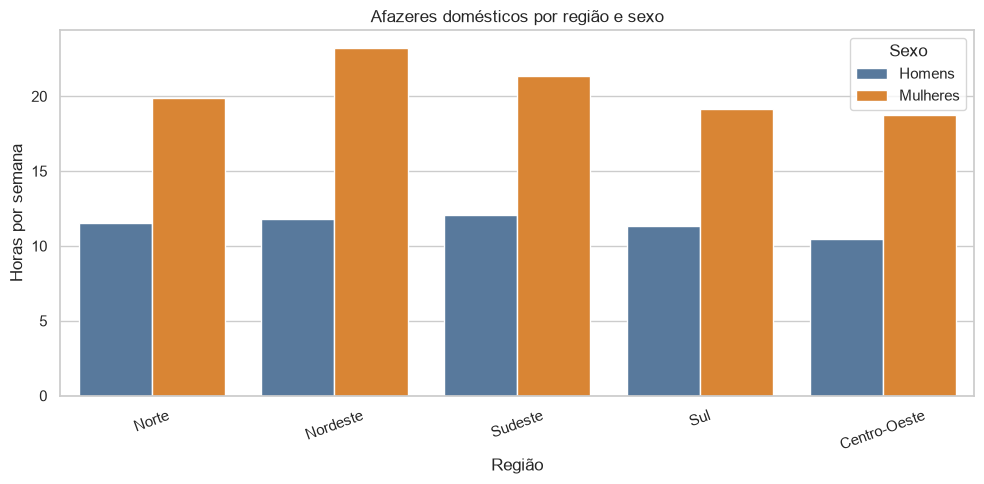

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=reg_long,
    x='uf_regiao',
    y='Horas',
    hue='Sexo',
    hue_order=['Homens', 'Mulheres'],
    palette=palette,
    ax=ax,
)
ax.set_title('Afazeres domésticos por região e sexo')
ax.set_xlabel('Região')
ax.set_ylabel('Horas por semana')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

## Atividade 3 — Formação acadêmica no Brasil

Barras agrupadas para comparar homens e mulheres em três áreas de formação.

In [4]:
bruto_3 = pd.read_excel(
    projeto / 'atividade3' / 'Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx',
    sheet_name='Sheet1',
    header=None,
)

dados_3 = bruto_3.iloc[3:36].copy()
dados_3.columns = [
    'regiao',
    'sup_total',
    'sup_homens',
    'sup_mulheres',
    'stem_total',
    'stem_homens',
    'stem_mulheres',
    'saude_total',
    'saude_homens',
    'saude_mulheres',
]
dados_3 = dados_3.reset_index(drop=True)

for coluna in dados_3.columns[1:]:
    dados_3[coluna] = pd.to_numeric(dados_3[coluna], errors='coerce')

formacao_total = dados_3[['regiao', 'sup_homens', 'sup_mulheres']].rename(
    columns={
        'regiao': 'uf_regiao',
        'sup_homens': 'homens',
        'sup_mulheres': 'mulheres',
    }
)
formacao_stem = dados_3[['regiao', 'stem_homens', 'stem_mulheres']].rename(
    columns={
        'regiao': 'uf_regiao',
        'stem_homens': 'homens',
        'stem_mulheres': 'mulheres',
    }
)
formacao_saude = dados_3[['regiao', 'saude_homens', 'saude_mulheres']].rename(
    columns={
        'regiao': 'uf_regiao',
        'saude_homens': 'homens',
        'saude_mulheres': 'mulheres',
    }
)

formacao_total.head()

,uf_regiao,homens,mulheres
0,Brasil,10478534,15375757
1,Norte,590558,934609
2,Nordeste,1744994,3003939
3,Sudeste,5391638,7437191
4,Sul,1768855,2570005


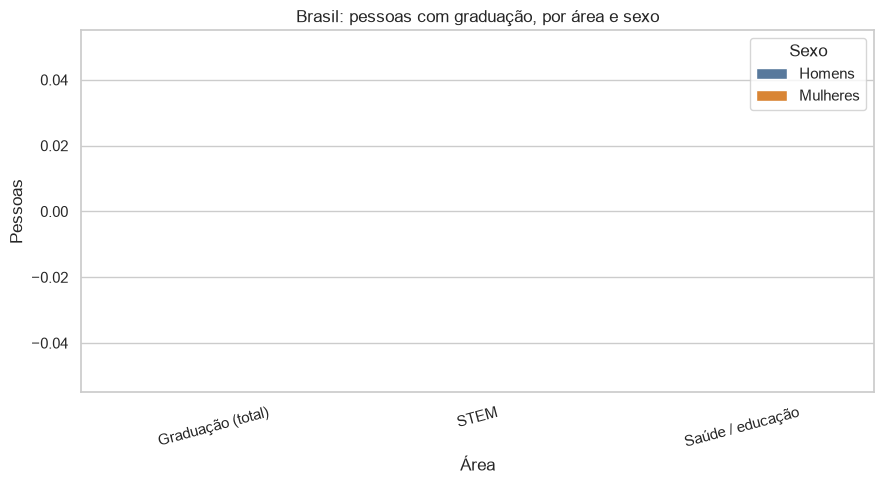

In [5]:
brasil = pd.DataFrame(
    {
        'area': ['Graduação (total)', 'STEM', 'Saúde / educação'],
        'homens': [
            formacao_total.loc[formacao_total['uf_regiao'] == 'Brasil', 'homens'].item(),
            formacao_stem.loc[formacao_stem['uf_regiao'] == 'Brasil', 'homens'].item(),
            formacao_saude.loc[formacao_saude['uf_regiao'] == 'Brasil', 'homens'].item(),
        ],
        'mulheres': [
            formacao_total.loc[formacao_total['uf_regiao'] == 'Brasil', 'mulheres'].item(),
            formacao_stem.loc[formacao_stem['uf_regiao'] == 'Brasil', 'mulheres'].item(),
            formacao_saude.loc[formacao_saude['uf_regiao'] == 'Brasil', 'mulheres'].item(),
        ],
    }
)
brasil_long = brasil.melt(
    id_vars='area',
    var_name='Sexo',
    value_name='Pessoas',
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=brasil_long,
    x='area',
    y='Pessoas',
    hue='Sexo',
    hue_order=['Homens', 'Mulheres'],
    palette=palette,
    ax=ax,
)
ax.set_title('Brasil: pessoas com graduação, por área e sexo')
ax.set_xlabel('Área')
ax.set_ylabel('Pessoas')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
plt.show()

## Atividade 4 — População de 2022 por UF

Barras horizontais ordenadas pela população do Censo de 2022.

In [6]:
bruto_4 = pd.read_excel(
    projeto / 'atividade4' / 'CD2022_Populacao_2010_Compatibilizada_20231222.xlsx',
    header=None,
    skiprows=2,
)
bruto_4.columns = [
    'lixo',
    'UF',
    'COD_UF',
    'COD_MUNIC',
    'NOME_MUNICIPIO',
    'POP_2010_SINOPSE',
    'POP_2010_COMPATIBILIZADA',
    'POP_2022',
]
bruto_4 = bruto_4.drop(columns=['lixo'])

for coluna in ['POP_2010_SINOPSE', 'POP_2010_COMPATIBILIZADA', 'POP_2022']:
    bruto_4[coluna] = pd.to_numeric(bruto_4[coluna], errors='coerce')

ufs = [
    'AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT',
    'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO',
]
pop_estado = (
    bruto_4.loc[bruto_4['UF'].isin(ufs), ['UF', 'POP_2010_COMPATIBILIZADA', 'POP_2022']]
    .groupby('UF', as_index=False)[['POP_2010_COMPATIBILIZADA', 'POP_2022']]
    .sum()
)
pop_estado = pop_estado.rename(columns={'POP_2022': '2022'})
pop_estado = pop_estado.sort_values('2022', ascending=False).reset_index(drop=True)

pop_estado

,UF,POP_2010_COMPATIBILIZADA,2022
0,SP,41262199.0,44411238.0
1,MG,19597330.0,20539989.0
2,RJ,15989929.0,16055174.0
3,BA,14017071.0,14141626.0
4,PR,10444526.0,11444380.0
5,RS,10693929.0,10882965.0
6,PE,8796055.0,9058931.0
7,CE,8451644.0,8794957.0
8,PA,7581051.0,8120131.0
9,SC,6248436.0,7610361.0


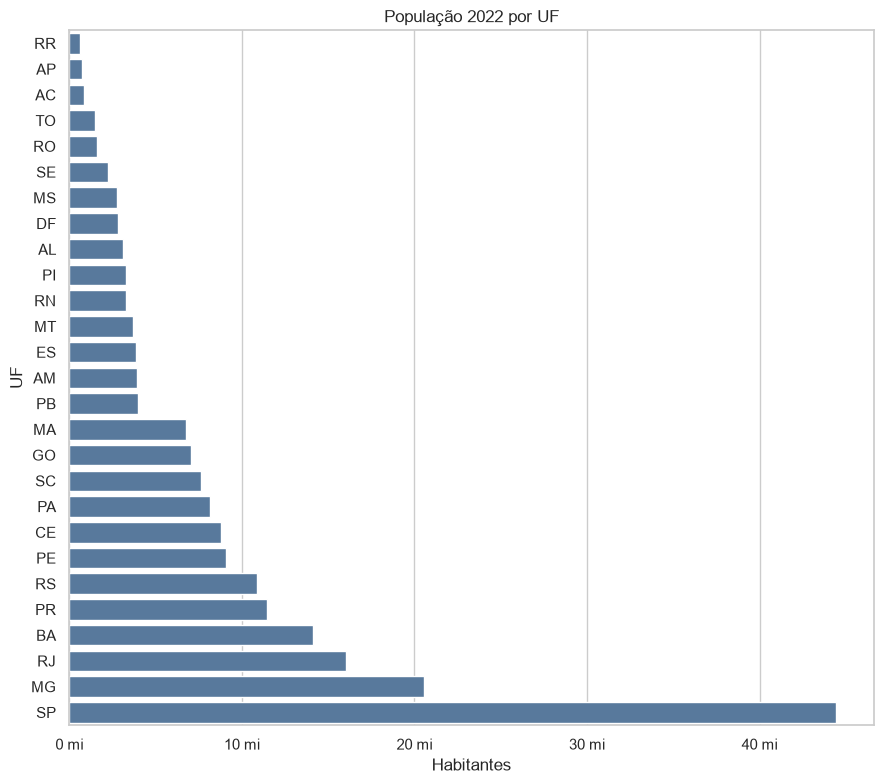

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(
    data=pop_estado,
    y='UF',
    x='2022',
    color='#4C78A8',
    ax=ax,
)
ax.set_title('População 2022 por UF')
ax.set_xlabel('Habitantes')
ax.set_ylabel('UF')
ax.xaxis.set_major_formatter(FuncFormatter(lambda valor, _: f'{valor / 1_000_000:.0f} mi'))
ax.invert_yaxis()
fig.tight_layout()
plt.show()